In [ ]:
import os 
import torch
import random
from diffusers import StableDiffusionPipeline
from safetensors.torch import load_file
from copy import deepcopy
torch.enable_grad(False)
from types import MethodType

from diffusers import (
    AutoencoderKL,
    DDPMScheduler,
    DiffusionPipeline,
    DPMSolverMultistepScheduler,
    DDIMScheduler,
    StableDiffusionPipeline,
    UNet2DConditionModel,
)
from esd.utils.surgery_util import custom_call
# StableDiffusionPipeline.__call__ = custom_call


# Overwrite and Return Pipeline Call

In [2]:
torch_dtype = torch.bfloat16
device = 'cuda:0'
basemodel_id="CompVis/stable-diffusion-v1-4"



pipe = StableDiffusionPipeline.from_pretrained(basemodel_id, torch_dtype=torch_dtype, use_safetensors=True, safety_checker=None).to(device)
original_weights = deepcopy(pipe.unet.state_dict())
# esd_weights = load_file("../esd-models/sd/esd-golden_retriever-from-golden_retriever-esdu.safetensors")

pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

/home/nessessence/anaconda3/envs/uul/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please

In [3]:
num_inference_steps = 20
height=width=512
guidance_scale = 7.5

In [4]:
prompt = 'image of a golden retriever'
seed = 1234

  0%|          | 0/20 [00:00<?, ?it/s]

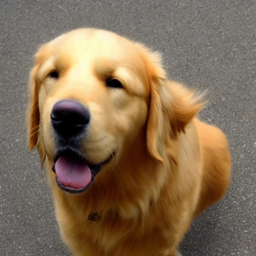

In [5]:
# Original Pipeline Call

pipe.unet.load_state_dict(original_weights, strict=False)
image = pipe(prompt, 
             num_inference_steps = num_inference_steps,
             guidance_scale= guidance_scale,

             generator=torch.Generator().manual_seed(seed)
            ).images
image[0].resize((256,256))

  0%|          | 0/20 [00:00<?, ?it/s]

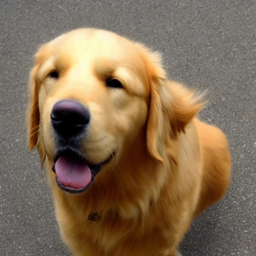

20 - torch.Size([1, 4, 64, 64])
20 - [tensor(951, device='cuda:0'), tensor(901, device='cuda:0'), tensor(851, device='cuda:0'), tensor(801, device='cuda:0'), tensor(751, device='cuda:0'), tensor(701, device='cuda:0'), tensor(651, device='cuda:0'), tensor(601, device='cuda:0'), tensor(551, device='cuda:0'), tensor(501, device='cuda:0'), tensor(451, device='cuda:0'), tensor(401, device='cuda:0'), tensor(351, device='cuda:0'), tensor(301, device='cuda:0'), tensor(251, device='cuda:0'), tensor(201, device='cuda:0'), tensor(151, device='cuda:0'), tensor(101, device='cuda:0'), tensor(51, device='cuda:0'), tensor(1, device='cuda:0')]


In [6]:

# Custom Pipeline Call
OriginalPipeClass = pipe.__class__
OneOffPipe = type("OneOffPipe", (OriginalPipeClass,), {"__call__": custom_call})
pipe.__class__ = OneOffPipe  # use custom_call

outputs = pipe(prompt, 
             num_inference_steps = num_inference_steps,
             guidance_scale= guidance_scale,
             generator=torch.Generator().manual_seed(seed),
             save_every_step_latents = True
            )
display(outputs.images[0].resize((256,256)))

print(f'{len(outputs.step_latents)} - {outputs.step_latents[0].shape}')
print(f'{len(outputs.step_timesteps)} - {outputs.step_timesteps}')


  0%|          | 0/20 [00:00<?, ?it/s]

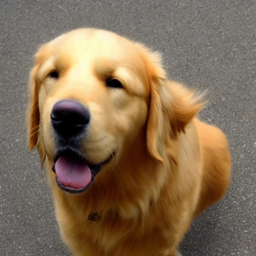

AttributeError: 'StableDiffusionPipelineOutput' object has no attribute 'step_latents'

In [7]:

# Return to original class

pipe.__class__ = pipe.__class__.__bases__[0]


outputs = pipe(prompt, 
             num_inference_steps = num_inference_steps,
             guidance_scale= guidance_scale,
             generator=torch.Generator().manual_seed(seed),
             save_every_step_latents = True
            )
display(outputs.images[0].resize((256,256)))

print(f'{len(outputs.step_latents)} - {outputs.step_latents[0].shape}')
print(f'{len(outputs.step_timesteps)} - {outputs.step_timesteps}')
